# Milestone 2 — Baselines

Reference models that every later model (matrix factorization, two-tower) must beat
to justify its complexity. Logic lives in `src/`; this notebook runs it, shows the
numbers, and interprets them.

- **Popularity** — recommend the globally most-popular items to everyone.
- **Matrix factorization**

Evaluation: chronological `val` split, macro-averaged ranking metrics
(precision / recall / NDCG / hit-rate @ k), relevance = held-out interactions rated ≥ 4.

## Setup

Notebook launches with their own folder as the workoing directory. We switch to the project root so that `import src...` resolves properly and pipeline's default `data/processed` path works unchanged.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from src.recommend.baselines import popularity_baseline_pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option('display.max_columns', 100)
plt.style.use('ggplot')

print("Working dir:", Path.cwd())


Working dir: C:\Users\Nikolaa\PycharmProjects\RecoSearch


## Popularity baseline

Rank items by how many **positive** (rating >= 4) interactions they got in `train`. Recommend such list to everyone ( except items each user already saw in train) and evaluate on `val`. Non-personalized but usually a strong floor because interactions data is heavily concentrated on a few popular items.

In [2]:
report_pos, recs_pos = popularity_baseline_pipeline()
report_pos

2026-09-13 14:35:50,098 - src.evaluation.metrics - INFO - Built ground truth for 81632 users from 133946 positive interactions (rating >= 4).
2026-09-13 14:35:50,621 - src.recommend.baselines - INFO - Computed item popularity by=positive_count: 27135 items ranked from 1041605 interactions. Top item has 7970 hits.
2026-09-13 14:36:12,596 - src.recommend.baselines - INFO - Built seen-item set for 445342 training users.
2026-09-13 14:36:13,069 - src.recommend.baselines - INFO - Popularity baseline (by=positive_count) on val:
2026-09-13 14:36:15,372 - src.evaluation.metrics - INFO - Ranking metrics:
    precision  recall   ndcg  hit_rate  n_users
k                                              
5      0.0032  0.0098 0.0071    0.0157    81632
10     0.0022  0.0136 0.0084    0.0218    81632
20     0.0020  0.0259 0.0119    0.0394    81632


,precision,recall,ndcg,hit_rate,n_users
k,,,,,
5,0.0032,0.0098,0.0071,0.0157,81632
10,0.0022,0.0136,0.0084,0.0218,81632
20,0.0020,0.0259,0.0119,0.0394,81632


### Does the popularity *definition* matter?

Compare ranking by positive-count (people who **liked** it) vs. raw interaction count
(people who **touched** it, regardless of rating). If they're nearly identical, this
dataset's popular items are also its well-liked items; if positive-count wins, rating
signal adds something over raw volume.

In [3]:
report_count, recs_count = popularity_baseline_pipeline(by="count")

comparison = pd.concat(
    {"positive_count": report_pos, "raw_count": report_count},
    names=["popularity_by"],
)
comparison

2026-09-13 14:36:29,913 - src.evaluation.metrics - INFO - Built ground truth for 81632 users from 133946 positive interactions (rating >= 4).
2026-09-13 14:36:30,067 - src.recommend.baselines - INFO - Computed item popularity by=count: 27373 items ranked from 1324774 interactions. Top item has 8593 hits.
2026-09-13 14:36:52,851 - src.recommend.baselines - INFO - Built seen-item set for 445342 training users.
2026-09-13 14:36:53,267 - src.recommend.baselines - INFO - Popularity baseline (by=count) on val:
2026-09-13 14:36:55,533 - src.evaluation.metrics - INFO - Ranking metrics:
    precision  recall   ndcg  hit_rate  n_users
k                                              
5      0.0032  0.0098 0.0073    0.0157    81632
10     0.0017  0.0105 0.0075    0.0168    81632
20     0.0019  0.0253 0.0116    0.0379    81632


precision  recall   ndcg  hit_rate  n_users
popularity_by  k                                              
positive_count 5      0.0032  0.0098 0.0071    0.0157    81632
               10     0.0022  0.0136 0.0084    0.0218    81632
               20     0.0020  0.0259 0.0119    0.0394    81632
raw_count      5      0.0032  0.0098 0.0073    0.0157    81632
               10     0.0017  0.0105 0.0075    0.0168    81632
               20     0.0019  0.0253 0.0116    0.0379    81632

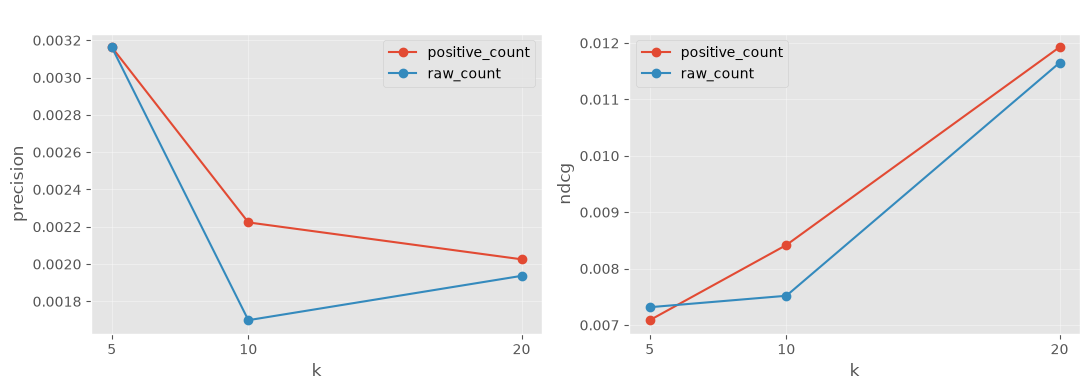

In [5]:
# Visualize both definitions across k for the two headline metrics.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["precision", "ndcg"]):
    for mode, rep in [("positive_count", report_pos), ("raw_count", report_count)]:
        ax.plot(rep.index, rep[metric], marker="o", label=mode)
    ax.set_title(f"{metric}@k — popularity baseline")
    ax.set_xlabel("k")
    ax.set_ylabel(metric)
    ax.set_xticks(report_pos.index)
    ax.legend(labelcolor="black")
fig.tight_layout()
plt.show()

### Sanity check: what is popularity actually recommending?

A non-personalized model should be recommending recognizable blockbuster items to
*everyone*. Joining the top items back to their titles is both a correctness check and
a preview of the "coverage trap" — the same handful of items go to every user.

In [8]:
from src.recommend.baselines import compute_item_popularity

train = pd.read_parquet("data/processed/train.parquet")
meta = pd.read_parquet("data/processed/metadata_clean.parquet")

_, counts = compute_item_popularity(train, by="positive_count")
top10 = (
    counts.head(10)
    .rename("positive_count")
    .reset_index()
    .merge(meta[["parent_asin", "title"]], on="parent_asin", how="left")
)
top10

Computed item popularity by=positive_count: 27135 items ranked from 1041605 interactions. Top item has 7970 hits.


,parent_asin,positive_count,title
0,B01N3ASPNV,7970,amFilm Tempered Glass Screen Protector for Nin...
1,B0086VPUHI,5232,Grand Theft Auto V: Premium Edition - Xbox One...
2,B07YBXFDYN,4788,Skyrim VR - PlayStation 4
3,B077GG9D5D,4658,DualShock 4 Wireless Controller for PlayStatio...
4,B000N5Z2L4,4590,Xbox Live Gold: 1 Month Membership [Digital Code]
5,B00BGA9WK2,3900,PlayStation 4 500GB Console [Old Model][Discon...
6,B07YBWT3PK,3452,Fallout 4 - Xbox One
7,B07624RBWB,2418,Nintendo Switch Pro Controller
8,B07K3KHFSY,2373,Nyko Charge Base - 2 Port Controller Charger w...
9,B00BGA9X9W,2163,DualShock 4 Wireless Controller for PlayStatio...


### Interpretation

- **Floor:** precision@10 ≈ 0.2%, NDCG@10 ≈ 0.8%, hit_rate@20 ≈ 3.9%, over 81,632 scored
  val users. Low in absolute terms (expected with ~27k items); this is the bar later
  models must clear. Headline number to beat: **hit_rate@20 ≈ 3.9%**.
- **positive_count vs raw_count:** tied at k=5, but positive_count is ~30% better on
  recall@10 and hit_rate@10. The head of both lists is identical (top items are both
  most-reviewed *and* most-liked); rating signal only reorders items deeper in the list.
  This validates defining relevance by rating ≥ 4.
- **Precision falls with k while recall/hit-rate rise** — the precision–recall tradeoff.
- Popularity sends the *same* items to all 81,632 users → near-zero catalog coverage.
  Its accuracy is a floor; its coverage is the weakness personalization will fix.

## Matrix factorization (BPR) baseline

First real model. Learns a 64-dim embedding per user and per item; score = dot
product + item bias; trained with BPR (positive should outrank a sampled negative).
Evaluated on **warm users** (val users also seen in train) so it's comparable to
popularity on the same population — MF cannot score cold-start users at all.

In [6]:
from src.recommend.mf import mf_baseline_pipeline

mf = mf_baseline_pipeline(epochs=20)
mf["report"]

C:\Users\Nikolaa\PycharmProjects\RecoSearch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-13 14:37:25,890 - src.recommend.mf - INFO - Training MF on device=cuda
2026-09-13 14:37:28,509 - src.recommend.mf - INFO - Built id mappings: 445342 users, 27373 items.
2026-09-13 14:37:32,088 - src.recommend.mf - INFO - BPRDataset: 1041605 positive pairs (rating >= 4) over 445342 users.
2026-09-13 14:37:35,897 - src.evaluation.metrics - INFO - Built ground truth for 81632 users from 133946 positive interactions (rating >= 4).
2026-09-13 14:37:35,961 - src.recommend.mf - INFO - Warm eval users: 44708 of 81632 (54.8%).
2026-09-13 14:38:00,913 - src.recommend.mf - INFO - epoch 1/20 - train BPR loss 0.6408 - val ndcg@10 0.0061
2026-09-13 14:38:22,174 - src.recommend.mf - INFO - epoch 2/20 - train BPR loss 0.5488 

,precision,recall,ndcg,hit_rate,n_users
k,,,,,
5,0.0033,0.0133,0.0090,0.0165,44708
10,0.0026,0.0204,0.0114,0.0258,44708
20,0.0016,0.0242,0.0124,0.0312,44708


In [7]:
from src.evaluation.metrics import evaluate_recommendations

gt_warm = mf["gt_warm"]

# Re-score popularity on the SAME warm users (recs_pos already covers them).
pop_warm = evaluate_recommendations(recs_pos, gt_warm, k_values=(5, 10, 20))

head_to_head = pd.concat(
    {"popularity": pop_warm, "mf_bpr": mf["report"]},
    names=["model"],
)
head_to_head

2026-09-13 14:40:14,223 - src.evaluation.metrics - INFO - Ranking metrics:
    precision  recall   ndcg  hit_rate  n_users
k                                              
5      0.0025  0.0092 0.0061    0.0122    44708
10     0.0018  0.0134 0.0075    0.0179    44708
20     0.0016  0.0244 0.0105    0.0314    44708


precision  recall   ndcg  hit_rate  n_users
model      k                                              
popularity 5      0.0025  0.0092 0.0061    0.0122    44708
           10     0.0018  0.0134 0.0075    0.0179    44708
           20     0.0016  0.0244 0.0105    0.0314    44708
mf_bpr     5      0.0033  0.0133 0.0090    0.0165    44708
           10     0.0026  0.0204 0.0114    0.0258    44708
           20     0.0016  0.0242 0.0124    0.0312    44708

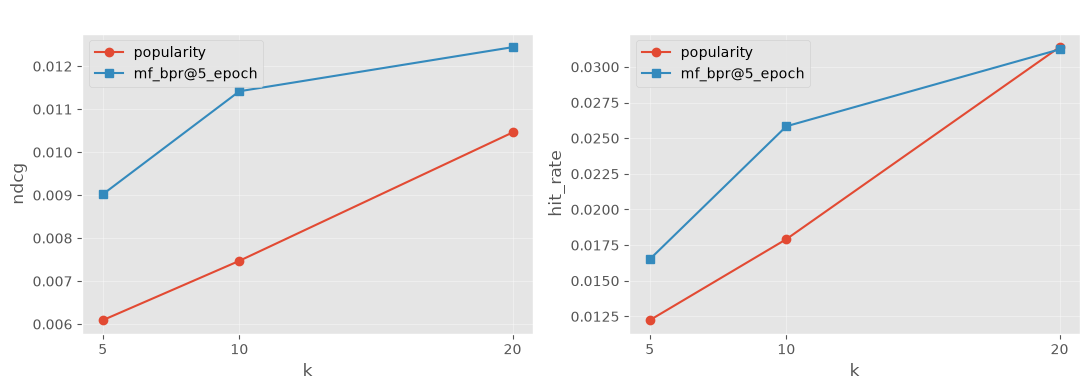

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["ndcg", "hit_rate"]):
    ax.plot(pop_warm.index, pop_warm[metric], marker="o", label="popularity")
    ax.plot(mf["report"].index, mf["report"][metric], marker="s", label="mf_bpr@5_epoch")
    ax.set_title(f"{metric}@k — warm users")
    ax.set_xlabel("k"); ax.set_ylabel(metric)
    ax.set_xticks(pop_warm.index); ax.legend(labelcolor="black")
fig.tight_layout()
plt.show()

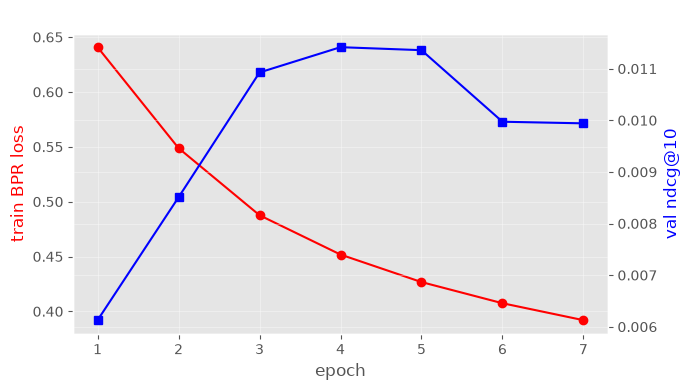

In [9]:
hist = mf["history"]
ep = range(1, len(hist["train_loss"]) + 1)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(ep, hist["train_loss"], "r-o", label="train BPR loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("train BPR loss", color="r")

ax2 = ax1.twinx()
ax2.plot(ep, hist["val_ndcg"], "b-s", label="val ndcg@10")
ax2.set_ylabel("val ndcg@10", color="b")

ax1.set_title("Training loss keeps falling; val NDCG peaks then overfits")
fig.tight_layout(); plt.show()

### Conclusion: MF beats popularity, but overfits without early stopping

BPR-MF beats the popularity baseline on the warm-user set (NDCG@10 and hit-rate),
so personalization adds real signal over "recommend the popular items".

**However, training loss and validation quality diverge.** Over 20 epochs the train
BPR loss keeps falling, but val NDCG@10 rises, peaks around epoch ~5, then declines (overfitting).
 In the early epochs the model learns *generalizable patterns*
(popular items, broad taste structure) that transfer to val; trained longer, it starts
*memorizing* training-specific interactions that don't generalize, so val degrades even
as train loss improves.

This is why the model is never selected by training loss. Early stopping on val NDCG@10
keeps the best-epoch weights and gives the reported numbers.

Likely contributing factors (capacity vs. data size): 64-dim embeddings on a sparse
dataset (many users with only 1–2 interactions) and light regularization
(weight_decay=1e-5). Follow-ups: lower embedding_dim (e.g. 32),
stronger weight_decay (1e-4/1e-3) should result in a model that will not overfit as early.